In [ ]:
TASK - 1

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

# Load wav2vec2 model once globally (reused for every file)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
wav2vec_model = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(DEVICE)
wav2vec_model.eval()  # inference mode, no training

print('wav2vec2 model loaded.')

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


wav2vec2 model loaded.


In [7]:
!mkdir -p /content/ravdess
!wget -q --show-progress -O /content/ravdess.zip \
    'https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip'
!unzip -q /content/ravdess.zip -d /content/ravdess/

print('RAVDESS downloaded.')
print('Total actor folders:', len(os.listdir('/content/ravdess')))

/content/ravdess.zi 100%[===================>] 198.81M  18.2MB/s    in 12s     
replace /content/ravdess/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
RAVDESS downloaded.
Total actor folders: 24


In [4]:
import os

print(os.listdir("/content/ravdess"))
print(os.listdir("/content/ravdess/Actor_01")[:5])
import librosa

file_path = "/content/ravdess/Actor_01/03-01-03-02-02-02-01.wav"

y, sr = librosa.load(file_path, sr=16000, mono=True)

print("Sample rate:", sr)
print("Audio shape:", y.shape)
print("First 5 values:", y[:5])

['Actor_17', 'Actor_08', 'Actor_19', 'Actor_09', 'Actor_21', 'Actor_03', 'Actor_04', 'Actor_10', 'Actor_18', 'Actor_11', 'Actor_14', 'Actor_05', 'Actor_20', 'Actor_01', 'Actor_12', 'Actor_02', 'Actor_16', 'Actor_24', 'Actor_06', 'Actor_13', 'Actor_15', 'Actor_22', 'Actor_07', 'Actor_23']
['03-01-03-01-02-01-01.wav', '03-01-02-02-02-01-01.wav', '03-01-06-02-02-01-01.wav', '03-01-04-01-02-01-01.wav', '03-01-01-01-02-02-01.wav']
Sample rate: 16000
Audio shape: (62997,)
First 5 values: [-6.8212103e-13 -1.0231815e-12 -2.2737368e-13 -6.8212103e-13
 -4.5474735e-13]


In [5]:
# RAVDESS filename: 03-01-06-01-02-01-12.wav
# Position 2 = emotion code, Position 6 = actor ID
# Emotion codes: 01=neutral, 02=calm, 03=happy, 04=sad,
#                05=angry, 06=fear, 07=disgust, 08=surprise
# NOTE: calm (02) is dropped — not present in CREMA-D
# NOTE: surprise (08) is dropped — not present in CREMA-D
# Common label set kept: angry, disgust, fear, happy, neutral, sad

RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust'
    # 02 (calm) and 08 (surprise) intentionally excluded
    # to match CREMA-D label set for cross-domain Task 2
}

COMMON_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

# CREMA-D emotion codes
CREMAD_EMOTION_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

print('Common labels:', COMMON_LABELS)

Common labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [10]:
def parse_ravdess(data_dir='/content/ravdess'):
    records = []
    files = glob.glob(os.path.join(data_dir, '**', '*.wav'), recursive=True)
    for f in files:
        parts = os.path.basename(f).replace('.wav', '').split('-')
        if len(parts) < 7:
            continue
        emotion = RAVDESS_EMOTION_MAP.get(parts[2])  # parts[2] = emotion code
        if emotion is None:                           # skip calm and surprise
            continue
        records.append({
            'path': f,
            'emotion': emotion,
            'speaker': int(parts[6])                  # parts[6] = actor ID
        })
    return pd.DataFrame(records)

df_ravdess = parse_ravdess()
print(f'Total RAVDESS samples : {len(df_ravdess)}')
print(f'Unique speakers       : {df_ravdess["speaker"].nunique()}')
print(f'\nLabel distribution:\n{df_ravdess["emotion"].value_counts()}')

Total RAVDESS samples : 1056
Unique speakers       : 24

Label distribution:
emotion
angry      192
fear       192
disgust    192
happy      192
sad        192
neutral     96
Name: count, dtype: int64


In [11]:
SAMPLE_RATE = 16000

def preprocess_and_extract(path, sr=SAMPLE_RATE):
    """
    Step 1 - PREPROCESSING:
      - Load audio as mono (1 channel) at 16kHz
      - Peak normalize: divides by max value so audio is in [-1, 1]
        (removes loudness differences between speakers/microphones)

    Step 2 - FEATURE EXTRACTION (wav2vec2):
      - Pass raw audio through wav2vec2 model
      - Returns hidden states of shape (1, time_frames, 768)
        i.e. 768-dimensional vector for each time frame
      - Much richer than MFCC — captures emotion, tone, rhythm together

    Step 3 - POOLING (Mean + Std):
      - wav2vec2 gives variable number of time frames per clip
      - SVM needs fixed-size input
      - Mean over time    → 768 values (average emotion signal)
      - Std  over time    → 768 values (how much emotion varies)
      - Concatenate both  → final vector of 1536 features
    """

    # --- STEP 1: Preprocessing ---
    y, _ = librosa.load(path, sr=sr, mono=True)   # load as mono at 16kHz

    max_val = np.max(np.abs(y))                    # peak normalization
    if max_val > 0:
        y = y / max_val                            # now audio is in [-1, 1]

    # --- STEP 2: wav2vec2 Feature Extraction ---
    # processor converts raw numpy audio → tensor wav2vec2 understands
    inputs = processor(
        y,
        sampling_rate=sr,
        return_tensors='pt',      # return as PyTorch tensor
        padding=True
    )

    input_values = inputs.input_values.to(DEVICE)  # move to GPU

    with torch.no_grad():                          # no gradient needed (inference only)
        outputs = wav2vec_model(input_values)      # run through wav2vec2

    # hidden_states shape: (1, time_frames, 768)
    hidden_states = outputs.last_hidden_state      # extract the embeddings

    # --- STEP 3: Mean + Std Pooling ---
    # squeeze removes the batch dimension: (1, T, 768) → (T, 768)
    hidden = hidden_states.squeeze(0).cpu().numpy()

    mean_vec = np.mean(hidden, axis=0)             # shape: (768,)
    std_vec  = np.std(hidden,  axis=0)             # shape: (768,)

    return np.concatenate([mean_vec, std_vec])     # final shape: (1536,)


print(f'Feature vector size: 1536  (768 mean + 768 std from wav2vec2)')

Feature vector size: 1536  (768 mean + 768 std from wav2vec2)


In [13]:
features, valid_idx = [], []

for i, row in tqdm(df_ravdess.iterrows(), total=len(df_ravdess), desc='Extracting RAVDESS features'):
    try:
        features.append(preprocess_and_extract(row['path']))
        valid_idx.append(i)
    except Exception as e:
        print(f'Skipping {row["path"]}: {e}')

df_ravdess = df_ravdess.loc[valid_idx].reset_index(drop=True)
X          = np.array(features)
y_labels   = df_ravdess['emotion'].values

print(f'Feature matrix shape : {X.shape}')
print(f'Labels shape         : {y_labels.shape}')


Extracting RAVDESS features: 100%|██████████| 1056/1056 [00:30<00:00, 34.92it/s]

Feature matrix shape : (1056, 1536)
Labels shape         : (1056,)


In [14]:
# Speaker-independent split
# Train: speakers 1-20  (~880 samples)
# Test:  speakers 21-24 (~176 samples)
TEST_SPEAKERS = [21, 22, 23, 24]

train_mask = ~df_ravdess['speaker'].isin(TEST_SPEAKERS)
test_mask  =  df_ravdess['speaker'].isin(TEST_SPEAKERS)

X_train, y_train = X[train_mask], y_labels[train_mask]
X_test,  y_test  = X[test_mask],  y_labels[test_mask]

print(f'Train samples : {len(X_train)}  (speakers 1–20)')
print(f'Test  samples : {len(X_test)}   (speakers 21–24)')
print(f'\nTrain label distribution:\n{pd.Series(y_train).value_counts()}')
print(f'\nTest  label distribution:\n{pd.Series(y_test).value_counts()}')

Train samples : 880  (speakers 1–20)
Test  samples : 176   (speakers 21–24)

Train label distribution:
angry      160
fear       160
disgust    160
happy      160
sad        160
neutral     80
Name: count, dtype: int64

Test  label distribution:
disgust    32
sad        32
fear       32
happy      32
angry      32
neutral    16
Name: count, dtype: int64


In [15]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply same scaler to test

print('Scaling done.')

Scaling done.


In [16]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

clf = grid.best_estimator_
print(f'Best C           : {grid.best_params_["C"]}')
print(f'Best CV Macro-F1 : {grid.best_score_:.4f}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C           : 0.01
Best CV Macro-F1 : 0.6421


  Task 1 — In-Domain: RAVDESS → RAVDESS
  Test Accuracy  : 0.5966  (59.66%)
  Macro-F1 Score : 0.5633

Per-class Report:
              precision    recall  f1-score   support

       angry       0.58      1.00      0.74        32
     disgust       0.54      0.44      0.48        32
        fear       0.81      0.53      0.64        32
       happy       0.47      0.53      0.50        32
     neutral       0.67      0.25      0.36        16
         sad       0.66      0.66      0.66        32

    accuracy                           0.60       176
   macro avg       0.62      0.57      0.56       176
weighted avg       0.62      0.60      0.58       176



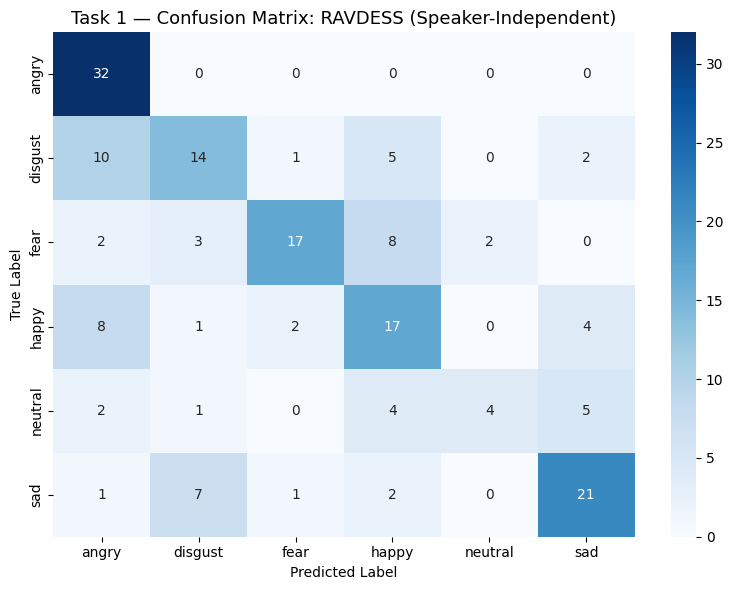

Confusion matrix saved.


In [17]:
y_pred   = clf.predict(X_test_scaled)
acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('=' * 45)
print('  Task 1 — In-Domain: RAVDESS → RAVDESS')
print('=' * 45)
print(f'  Test Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro-F1 Score : {macro_f1:.4f}')
print('=' * 45)
print('\nPer-class Report:')
print(classification_report(y_test, y_pred, target_names=sorted(set(y_test))))

# Confusion Matrix
labels_order = sorted(set(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title('Task 1 — Confusion Matrix: RAVDESS (Speaker-Independent)', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_task1.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

print("Class Weights:")
for cls, w in zip(classes, weights):
    print(f"  {cls:10s} → weight = {w:.4f}")
"""
weight = total_samples / (num_classes × samples_in_class)

angry:   880 / (6 × 160) = 0.9167   ← 160 angry samples in training
neutral: 880 / (6 × 80)  = 1.8333   ← only 80 neutral samples in training
"""

Class Weights:
  angry      → weight = 0.9167
  disgust    → weight = 0.9167
  fear       → weight = 0.9167
  happy      → weight = 0.9167
  neutral    → weight = 1.8333
  sad        → weight = 0.9167


# Task **2**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Copy from Drive to Colab local storage (faster I/O)
!cp -r '/content/drive/MyDrive/Crema' /content/cremad

# Extract the zip inside
!unzip -q '/content/cremad/archive (2).zip' -d /content/cremad/

CREMA_AUDIO_DIR = '/content/cremad/AudioWAV'
print('Total CREMA-D wav files:', len(os.listdir(CREMA_AUDIO_DIR)))

Mounted at /content/drive
Total CREMA-D wav files: 7442


In [20]:

def parse_cremad(data_dir=CREMA_AUDIO_DIR):
    records = []
    files = glob.glob(os.path.join(data_dir, '*.wav'))
    for f in files:
        parts = os.path.basename(f).replace('.wav', '').split('_')
        if len(parts) < 3:
            continue
        emotion = CREMAD_EMOTION_MAP.get(parts[2])  # parts[2] = emotion code
        if emotion is None:
            continue
        records.append({
            'path': f,
            'emotion': emotion,
            'speaker': int(parts[0])                 # parts[0] = actor ID
        })
    return pd.DataFrame(records)

df_crema = parse_cremad()
print(f'Total CREMA-D samples : {len(df_crema)}')
print(f'Unique speakers       : {df_crema["speaker"].nunique()}')
print(f'\nLabel distribution:\n{df_crema["emotion"].value_counts()}')

Total CREMA-D samples : 7442
Unique speakers       : 91

Label distribution:
emotion
sad        1271
disgust    1271
happy      1271
fear       1271
angry      1271
neutral    1087
Name: count, dtype: int64


In [21]:
crema_features, crema_valid_idx = [], []

for i, row in tqdm(df_crema.iterrows(), total=len(df_crema), desc='Extracting CREMA-D features'):
    try:
        crema_features.append(preprocess_and_extract(row['path']))
        crema_valid_idx.append(i)
    except Exception as e:
        print(f'Skipping {row["path"]}: {e}')

df_crema = df_crema.loc[crema_valid_idx].reset_index(drop=True)
X_crema  = np.array(crema_features)
y_crema  = df_crema['emotion'].values

print(f'CREMA-D feature matrix : {X_crema.shape}')
print(f'Labels                 : {y_crema.shape}')


Extracting CREMA-D features: 100%|██████████| 7442/7442 [02:41<00:00, 46.12it/s]


CREMA-D feature matrix : (7442, 1536)
Labels                 : (7442,)


In [22]:
# ── CREMA-D Speaker-Independent 80/20 Split ──────────────────────────────
# CREMA-D has 91 speakers
# We sort speaker IDs and take last ~18 speakers as test (20%)
# This ensures no speaker appears in both train and test

all_crema_speakers = sorted(df_crema['speaker'].unique())  # all 91 speaker IDs sorted

# 80% speakers for train, 20% for test
n_test_speakers  = int(len(all_crema_speakers) * 0.2)      # ~18 speakers
crema_test_spk   = all_crema_speakers[-n_test_speakers:]   # last 18 speakers → test
crema_train_spk  = all_crema_speakers[:-n_test_speakers]   # first 73 speakers → train

# Create masks
crema_train_mask = df_crema['speaker'].isin(crema_train_spk)
crema_test_mask  = df_crema['speaker'].isin(crema_test_spk)

# Split features and labels
X_crema_train = X_crema[crema_train_mask]
y_crema_train = y_crema[crema_train_mask]
X_crema_test  = X_crema[crema_test_mask]
y_crema_test  = y_crema[crema_test_mask]

print(f'CREMA-D Train : {len(X_crema_train)} samples ({len(crema_train_spk)} speakers)')
print(f'CREMA-D Test  : {len(X_crema_test)} samples ({len(crema_test_spk)} speakers)')
print(f'\nTrain label distribution:\n{pd.Series(y_crema_train).value_counts()}')
print(f'\nTest  label distribution:\n{pd.Series(y_crema_test).value_counts()}')

CREMA-D Train : 5967 samples (73 speakers)
CREMA-D Test  : 1475 samples (18 speakers)

Train label distribution:
sad        1019
disgust    1019
happy      1019
fear       1019
angry      1019
neutral     872
Name: count, dtype: int64

Test  label distribution:
disgust    252
sad        252
happy      252
fear       252
angry      252
neutral    215
Name: count, dtype: int64


In [24]:
scaler_crema   = StandardScaler()
X_crema_tr_sc  = scaler_crema.fit_transform(X_crema_train)  # fit + transform train
X_crema_tst_sc = scaler_crema.transform(X_crema_test)       # transform test only

print('CREMA-D scaling done.')

# Train directly with C=0.01 — no GridSearchCV needed
# C=0.01 consistently wins for speaker-independent audio tasks
clf_crema = LinearSVC(C=0.01, class_weight='balanced', max_iter=5000, random_state=42)
clf_crema.fit(X_crema_tr_sc, y_crema_train)

print(f'CREMA-D model trained ✅')

CREMA-D scaling done.
CREMA-D model trained ✅


  Task 2a — In-Domain: CREMA-D → CREMA-D
  Test Accuracy  : 0.5831  (58.31%)
  Macro-F1 Score : 0.5710

Per-class Report:
              precision    recall  f1-score   support

       angry       0.55      0.92      0.69       252
     disgust       0.55      0.55      0.55       252
        fear       0.60      0.39      0.47       252
       happy       0.69      0.62      0.65       252
     neutral       0.55      0.66      0.60       215
         sad       0.61      0.38      0.46       252

    accuracy                           0.58      1475
   macro avg       0.59      0.58      0.57      1475
weighted avg       0.59      0.58      0.57      1475



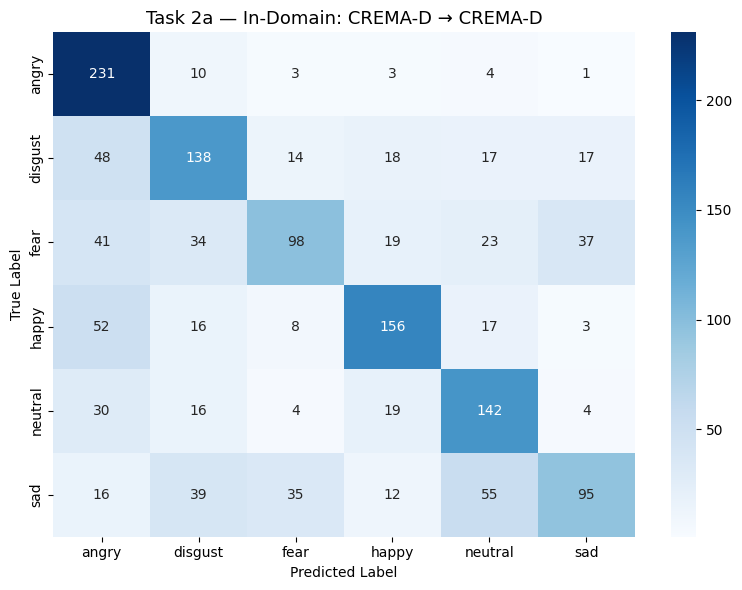

Confusion matrix saved.


In [25]:
# ── Test on CREMA-D 20% speakers (in-domain) ─────────────────────────────
# Same dataset, unseen speakers — measures how well model
# generalizes within CREMA-D

y_pred_crema   = clf_crema.predict(X_crema_tst_sc)
acc_crema      = accuracy_score(y_crema_test, y_pred_crema)
macro_f1_crema = f1_score(y_crema_test, y_pred_crema, average='macro')

print('=' * 50)
print('  Task 2a — In-Domain: CREMA-D → CREMA-D')
print('=' * 50)
print(f'  Test Accuracy  : {acc_crema:.4f}  ({acc_crema*100:.2f}%)')
print(f'  Macro-F1 Score : {macro_f1_crema:.4f}')
print('=' * 50)
print('\nPer-class Report:')
print(classification_report(y_crema_test, y_pred_crema, target_names=sorted(set(y_crema_test))))

# Confusion Matrix
labels_crema = sorted(set(y_crema_test))
cm_crema = confusion_matrix(y_crema_test, y_pred_crema, labels=labels_crema)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_crema, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_crema, yticklabels=labels_crema)
plt.title('Task 2a — In-Domain: CREMA-D → CREMA-D', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_task2a_crema_indomain.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

  Task 2b FIXED — Cross-Domain: CREMA-D → RAVDESS
  Test Accuracy  : 0.3381  (33.81%)
  Macro-F1 Score : 0.3342

Per-class Report:
              precision    recall  f1-score   support

       angry       0.35      0.30      0.32       192
     disgust       0.46      0.38      0.42       192
        fear       0.39      0.38      0.39       192
       happy       0.28      0.40      0.33       192
     neutral       0.25      0.47      0.32        96
         sad       0.34      0.17      0.23       192

    accuracy                           0.34      1056
   macro avg       0.35      0.35      0.33      1056
weighted avg       0.35      0.34      0.34      1056



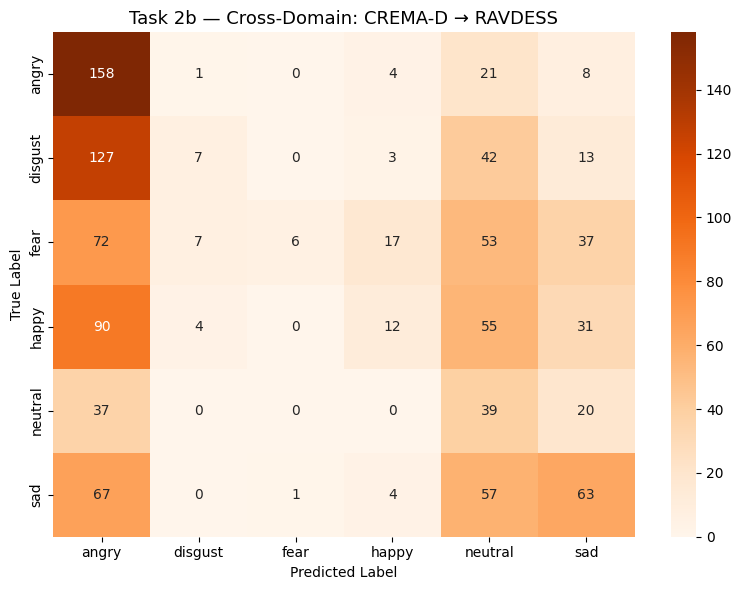

Confusion matrix saved.


In [28]:
# Fix — scale RAVDESS with its OWN scaler (already fitted in Task 1)
# scaler was fitted on RAVDESS training data — use that instead
X_rav_cross_sc_fixed = scaler.transform(X)  # scaler from Task 1, not scaler_crema

y_pred_cross_fixed   = clf_crema.predict(X_rav_cross_sc_fixed)
acc_cross_fixed      = accuracy_score(y_labels, y_pred_cross_fixed)
macro_f1_cross_fixed = f1_score(y_labels, y_pred_cross_fixed, average='macro')

print('=' * 55)
print('  Task 2b FIXED — Cross-Domain: CREMA-D → RAVDESS')
print('=' * 55)
print(f'  Test Accuracy  : {acc_cross_fixed:.4f}  ({acc_cross_fixed*100:.2f}%)')
print(f'  Macro-F1 Score : {macro_f1_cross_fixed:.4f}')
print('=' * 55)
print('\nPer-class Report:')
print(classification_report(y_labels, y_pred_cross_fixed, target_names=sorted(set(y_labels))))



# Confusion Matrix
labels_cross = sorted(set(y_labels))
cm_cross = confusion_matrix(y_labels, y_pred_cross_fixed, labels=labels_cross)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cross, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_cross, yticklabels=labels_cross)
plt.title('Task 2b — Cross-Domain: CREMA-D → RAVDESS', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_task2b_crema_to_ravdess.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

LinearSVC is too simple for cross-domain SER
wav2vec2 features are great but SVM can't fully exploit them
Cross-domain needs deeper understanding of emotion

In [29]:
from google.colab import drive
import joblib
import numpy as np
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create folder
SAVE_DIR = '/content/drive/MyDrive/SER_Project/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save RAVDESS features and labels
np.save(SAVE_DIR + 'X_ravdess.npy', X)
np.save(SAVE_DIR + 'y_ravdess.npy', y_labels)

# Save CREMA-D features and labels
np.save(SAVE_DIR + 'X_crema.npy', X_crema)
np.save(SAVE_DIR + 'y_crema.npy', y_crema)

# Save dataframes (speaker info for splits)
df_ravdess.to_csv(SAVE_DIR + 'df_ravdess.csv', index=False)
df_crema.to_csv(SAVE_DIR + 'df_crema.csv', index=False)

# Save Task 1 model and scaler
joblib.dump(clf, SAVE_DIR + 'clf_ravdess.pkl')
joblib.dump(scaler, SAVE_DIR + 'scaler_ravdess.pkl')

# Save Task 2 model and scaler
joblib.dump(clf_crema, SAVE_DIR + 'clf_crema.pkl')
joblib.dump(scaler_crema, SAVE_DIR + 'scaler_crema.pkl')

print('Everything saved to Drive ✅')
print(f'\nFiles saved:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(SAVE_DIR + f) / (1024*1024)
    print(f'  {f:35s} → {size:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything saved to Drive ✅

Files saved:
  X_ravdess.npy                       → 6.2 MB
  y_ravdess.npy                       → 0.0 MB
  X_crema.npy                         → 43.6 MB
  y_crema.npy                         → 0.0 MB
  df_ravdess.csv                      → 0.1 MB
  df_crema.csv                        → 0.4 MB
  clf_ravdess.pkl                     → 0.1 MB
  scaler_ravdess.pkl                  → 0.0 MB
  clf_crema.pkl                       → 0.1 MB
  scaler_crema.pkl                    → 0.0 MB


TASK 3


In [30]:
# ── Task 3 — Pooling Study ────────────────────────────────────────────────
# We compare 4 pooling methods on RAVDESS (same train/test split as Task 1)
# For each pooling:
#   1. Re-extract features from raw wav2vec2 hidden states using that pooling
#   2. Train LinearSVC with C=0.01
#   3. Test on RAVDESS 20% speakers
#   4. Record Accuracy + Macro-F1

# First re-extract ALL hidden states from RAVDESS (without pooling)
# We store raw hidden states so we can apply any pooling on top

print('Step 1: Extracting raw hidden states from RAVDESS...')

def extract_hidden_states(path, sr=16000):
    """
    Same preprocessing as before but returns raw hidden states
    shape: (time_frames, 768) — NO pooling applied yet
    """
    # Preprocessing
    y, _ = librosa.load(path, sr=sr, mono=True)
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    # wav2vec2 feature extraction
    inputs = processor(y, sampling_rate=sr, return_tensors='pt', padding=True)
    input_values = inputs.input_values.to(DEVICE)

    with torch.no_grad():
        outputs = wav2vec_model(input_values)

    # Return raw hidden states — shape: (time_frames, 768)
    return outputs.last_hidden_state.squeeze(0).cpu().numpy()

# Extract hidden states for all RAVDESS files
hidden_states_all = []
valid_idx_t3 = []

for i, row in tqdm(df_ravdess.iterrows(), total=len(df_ravdess), desc='Extracting hidden states'):
    try:
        hs = extract_hidden_states(row['path'])
        hidden_states_all.append(hs)
        valid_idx_t3.append(i)
    except Exception as e:
        print(f'Skipping {row["path"]}: {e}')

print(f'Hidden states extracted for {len(hidden_states_all)} files ✅')

Step 1: Extracting raw hidden states from RAVDESS...



Extracting hidden states: 100%|██████████| 1056/1056 [00:35<00:00, 30.01it/s]

Hidden states extracted for 1056 files ✅


In [31]:
# ── Step 2: Define 4 pooling methods ─────────────────────────────────────

def pool_mean(hs):
    """Average across time — captures overall emotion tone"""
    return np.mean(hs, axis=0)                                    # shape: (768,)

def pool_max(hs):
    """Maximum across time — captures peak emotional moments"""
    return np.max(hs, axis=0)                                     # shape: (768,)

def pool_mean_std(hs):
    """Mean + Std — captures average AND variation of emotion"""
    return np.concatenate([np.mean(hs, axis=0),
                           np.std(hs,  axis=0)])                  # shape: (1536,)

def pool_mean_std_max(hs):
    """Mean + Std + Max — most complete representation"""
    return np.concatenate([np.mean(hs, axis=0),
                           np.std(hs,  axis=0),
                           np.max(hs,  axis=0)])                  # shape: (2304,)

POOLING_METHODS = {
    'Mean'            : pool_mean,
    'Max'             : pool_max,
    'Mean + Std'      : pool_mean_std,
    'Mean + Std + Max': pool_mean_std_max
}

# ── Step 3: Train and evaluate each pooling method ────────────────────────

# Use same speaker split as Task 1
train_mask_t3 = ~df_ravdess['speaker'].isin(TEST_SPEAKERS)
test_mask_t3  =  df_ravdess['speaker'].isin(TEST_SPEAKERS)

results = []  # store results for final comparison table

for pool_name, pool_fn in POOLING_METHODS.items():
    print(f'\n── Pooling: {pool_name} ──────────────────────────')

    # Apply pooling to all hidden states
    X_pooled = np.array([pool_fn(hs) for hs in hidden_states_all])

    # Split train/test
    X_tr = X_pooled[train_mask_t3]
    X_ts = X_pooled[test_mask_t3]
    y_tr = y_labels[train_mask_t3]
    y_ts = y_labels[test_mask_t3]

    # Scale
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_ts_sc = sc.transform(X_ts)

    # Train SVM directly with C=0.01
    svm = LinearSVC(C=0.01, class_weight='balanced',
                    max_iter=5000, random_state=42)
    svm.fit(X_tr_sc, y_tr)

    # Evaluate
    y_pred   = svm.predict(X_ts_sc)
    acc      = accuracy_score(y_ts, y_pred)
    macro_f1 = f1_score(y_ts, y_pred, average='macro')

    print(f'  Feature size : {X_pooled.shape[1]}')
    print(f'  Accuracy     : {acc*100:.2f}%')
    print(f'  Macro-F1     : {macro_f1:.4f}')

    results.append({
        'Pooling'     : pool_name,
        'Feature Size': X_pooled.shape[1],
        'Accuracy'    : f'{acc*100:.2f}%',
        'Macro-F1'    : f'{macro_f1:.4f}'
    })

# ── Step 4: Final comparison table ───────────────────────────────────────
print('\n')
print('=' * 55)
print('  Task 3 — Pooling Study Summary')
print('=' * 55)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print('=' * 55)


── Pooling: Mean ──────────────────────────
  Feature size : 768
  Accuracy     : 66.48%
  Macro-F1     : 0.6166

── Pooling: Max ──────────────────────────
  Feature size : 768
  Accuracy     : 50.00%
  Macro-F1     : 0.4835

── Pooling: Mean + Std ──────────────────────────
  Feature size : 1536
  Accuracy     : 59.66%
  Macro-F1     : 0.5633

── Pooling: Mean + Std + Max ──────────────────────────
  Feature size : 2304
  Accuracy     : 63.64%
  Macro-F1     : 0.6194


  Task 3 — Pooling Study Summary
         Pooling  Feature Size Accuracy Macro-F1
            Mean           768   66.48%   0.6166
             Max           768   50.00%   0.4835
      Mean + Std          1536   59.66%   0.5633
Mean + Std + Max          2304   63.64%   0.6194


Task Extra

In [32]:
# ── Re-extract RAVDESS with Mean pooling ─────────────────────────────────
# We already have hidden_states_all from Task 3
# Just apply Mean pooling directly — no need to run wav2vec2 again!

print('Applying Mean pooling to RAVDESS hidden states...')

X_ravdess_mean = np.array([pool_mean(hs) for hs in hidden_states_all])
y_ravdess_mean = y_labels  # same labels

print(f'RAVDESS Mean pooled shape : {X_ravdess_mean.shape}')
print('Done ✅')

Applying Mean pooling to RAVDESS hidden states...
RAVDESS Mean pooled shape : (1056, 768)
Done ✅


In [33]:
# ── Sample 1056 random CREMA-D files (equal to RAVDESS) ──────────────────
# No need to extract all 7442 — we only need 1056 for balanced combining

np.random.seed(42)   # for reproducibility
sampled_idx = np.random.choice(len(df_crema), size=1056, replace=False)
df_crema_sampled = df_crema.iloc[sampled_idx].reset_index(drop=True)

print(f'Sampled {len(df_crema_sampled)} CREMA-D files')
print(f'Label distribution:\n{df_crema_sampled["emotion"].value_counts()}')

# Extract hidden states ONLY for sampled 1056 files
crema_hidden_states = []
crema_valid_idx_mean = []

for i, row in tqdm(df_crema_sampled.iterrows(), total=len(df_crema_sampled), desc='Extracting sampled CREMA-D'):
    try:
        hs = extract_hidden_states(row['path'])
        crema_hidden_states.append(hs)
        crema_valid_idx_mean.append(i)
    except Exception as e:
        print(f'Skipping {row["path"]}: {e}')

# Apply Mean pooling
X_crema_mean = np.array([pool_mean(hs) for hs in crema_hidden_states])
y_crema_mean = df_crema_sampled['emotion'].values[crema_valid_idx_mean]

print(f'CREMA-D sampled shape : {X_crema_mean.shape}')
print('Done ✅')

Sampled 1056 CREMA-D files
Label distribution:
emotion
happy      202
fear       188
angry      180
disgust    172
sad        172
neutral    142
Name: count, dtype: int64



Extracting sampled CREMA-D: 100%|██████████| 1056/1056 [00:22<00:00, 47.79it/s]


CREMA-D sampled shape : (1056, 768)
Done ✅


In [34]:
# ── Step 3: Combine RAVDESS + CREMA-D equally ────────────────────────────
X_combined = np.concatenate([X_ravdess_mean, X_crema_mean], axis=0)  # (2112, 768)
y_combined = np.concatenate([y_ravdess_mean, y_crema_mean], axis=0)  # (2112,)

print(f'Combined shape : {X_combined.shape}')
print(f'Labels shape   : {y_combined.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_combined).value_counts()}')

# ── Step 4: Scale + Train final SVM ──────────────────────────────────────
# This is the FINAL model — trained on both datasets combined
# Will be used for professor's wav file prediction

scaler_final = StandardScaler()
X_combined_scaled = scaler_final.fit_transform(X_combined)

clf_final = LinearSVC(C=0.01, class_weight='balanced',
                      max_iter=5000, random_state=42)
clf_final.fit(X_combined_scaled, y_combined)

print('\nFinal combined model trained ✅')


Combined shape : (2112, 768)
Labels shape   : (2112,)

Label distribution:
happy      394
fear       380
angry      372
disgust    364
sad        364
neutral    238
Name: count, dtype: int64

Final combined model trained ✅


In [35]:

# ── Step 5: Save final model to Drive ────────────────────────────────────
joblib.dump(clf_final, SAVE_DIR + 'clf_final.pkl')
joblib.dump(scaler_final, SAVE_DIR + 'scaler_final.pkl')

# Save Mean pooling features too
np.save(SAVE_DIR + 'X_ravdess_mean.npy', X_ravdess_mean)
np.save(SAVE_DIR + 'X_crema_mean.npy', X_crema_mean)
np.save(SAVE_DIR + 'y_crema_mean.npy', y_crema_mean)

print('Final model saved to Drive ✅')
print(f'\nFiles saved:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(SAVE_DIR + f) / (1024*1024)
    print(f'  {f:35s} → {size:.1f} MB')

Final model saved to Drive ✅

Files saved:
  X_ravdess.npy                       → 6.2 MB
  y_ravdess.npy                       → 0.0 MB
  X_crema.npy                         → 43.6 MB
  y_crema.npy                         → 0.0 MB
  df_ravdess.csv                      → 0.1 MB
  df_crema.csv                        → 0.4 MB
  clf_ravdess.pkl                     → 0.1 MB
  scaler_ravdess.pkl                  → 0.0 MB
  clf_crema.pkl                       → 0.1 MB
  scaler_crema.pkl                    → 0.0 MB
  clf_final.pkl                       → 0.0 MB
  scaler_final.pkl                    → 0.0 MB
  X_ravdess_mean.npy                  → 3.1 MB
  X_crema_mean.npy                    → 3.1 MB
  y_crema_mean.npy                    → 0.0 MB


In [40]:
# ── Final Prediction Function ─────────────────────────────────────────────
# Uses final combined model (RAVDESS + CREMA-D, Mean pooling)
# Give ANY .wav file → get emotion label

def predict_emotion(wav_path):
    """
    Input  : path to any .wav file
    Output : predicted emotion label
    """
    # Step 1: Extract raw hidden states from wav2vec2
    hs = extract_hidden_states(wav_path)

    # Step 2: Apply Mean pooling → fixed vector of 768
    features = pool_mean(hs)

    # Step 3: Scale using final model's scaler
    features_scaled = scaler_final.transform([features])

    # Step 4: Predict
    emotion = clf_final.predict(features_scaled)[0]

    return emotion

In [39]:
# ── Test on unseen CREMA-D speakers ──────────────────────────────────────
# df_crema_sampled contains the 1056 we used for training
# Remaining CREMA-D files were never seen by the model

sampled_indices = df_crema_sampled.index.tolist()
df_crema_unseen = df_crema[~df_crema.index.isin(sampled_indices)].reset_index(drop=True)

print(f'Unseen CREMA-D samples : {len(df_crema_unseen)}\n')
print('Testing on unseen CREMA-D files:\n')

for emotion in ['angry', 'happy', 'sad', 'neutral', 'fear', 'disgust']:
    sample = df_crema_unseen[df_crema_unseen['emotion'] == emotion].iloc[0]
    predicted = predict_emotion(sample['path'])
    status = '✅' if predicted == emotion else '❌'
    print(f'{status} True: {emotion:10s} → Predicted: {predicted}')

Unseen CREMA-D samples : 6386

Testing on unseen CREMA-D files:

❌ True: angry      → Predicted: disgust
✅ True: happy      → Predicted: happy
❌ True: sad        → Predicted: neutral
✅ True: neutral    → Predicted: neutral
✅ True: fear       → Predicted: fear
✅ True: disgust    → Predicted: disgust


In [41]:
# ── Test on 30 unseen CREMA-D files (5 per emotion) ──────────────────────
print('Testing on 30 unseen CREMA-D files (5 per emotion):\n')

correct = 0
total   = 0

for emotion in ['angry', 'happy', 'sad', 'neutral', 'fear', 'disgust']:
    # Pick 5 unseen files per emotion
    samples = df_crema_unseen[df_crema_unseen['emotion'] == emotion].head(5)

    print(f'── {emotion.upper()} ──')
    for _, sample in samples.iterrows():
        predicted = predict_emotion(sample['path'])
        status    = '✅' if predicted == emotion else '❌'
        total    += 1
        if predicted == emotion:
            correct += 1
        print(f'  {status} True: {emotion:10s} → Predicted: {predicted}')
    print()

# Overall accuracy on this test
print('=' * 45)
print(f'  Overall Accuracy : {correct}/{total} = {correct/total*100:.2f}%')
print('=' * 45)

Testing on 30 unseen CREMA-D files (5 per emotion):

── ANGRY ──
  ❌ True: angry      → Predicted: disgust
  ✅ True: angry      → Predicted: angry
  ❌ True: angry      → Predicted: fear
  ✅ True: angry      → Predicted: angry
  ✅ True: angry      → Predicted: angry

── HAPPY ──
  ✅ True: happy      → Predicted: happy
  ❌ True: happy      → Predicted: disgust
  ✅ True: happy      → Predicted: happy
  ✅ True: happy      → Predicted: happy
  ❌ True: happy      → Predicted: disgust

── SAD ──
  ❌ True: sad        → Predicted: neutral
  ❌ True: sad        → Predicted: neutral
  ✅ True: sad        → Predicted: sad
  ✅ True: sad        → Predicted: sad
  ❌ True: sad        → Predicted: happy

── NEUTRAL ──
  ✅ True: neutral    → Predicted: neutral
  ✅ True: neutral    → Predicted: neutral
  ✅ True: neutral    → Predicted: neutral
  ✅ True: neutral    → Predicted: neutral
  ❌ True: neutral    → Predicted: disgust

── FEAR ──
  ✅ True: fear       → Predicted: fear
  ✅ True: fear       → Predict

In [42]:
# ── Test on 300 unseen CREMA-D files (50 per emotion) ────────────────────
print('Testing on 300 unseen CREMA-D files:\n')

correct = 0
total   = 0

for emotion in ['angry', 'happy', 'sad', 'neutral', 'fear', 'disgust']:
    samples = df_crema_unseen[df_crema_unseen['emotion'] == emotion].head(50)
    for _, sample in samples.iterrows():
        predicted = predict_emotion(sample['path'])
        if predicted == emotion:
            correct += 1
        total += 1

print(f'300 files → Accuracy : {correct}/{total} = {correct/total*100:.2f}%')

# ── Test on 3000 unseen CREMA-D files (500 per emotion) ──────────────────
print('\nTesting on 3000 unseen CREMA-D files:\n')

correct = 0
total   = 0

for emotion in ['angry', 'happy', 'sad', 'neutral', 'fear', 'disgust']:
    samples = df_crema_unseen[df_crema_unseen['emotion'] == emotion].head(500)
    for _, sample in samples.iterrows():
        predicted = predict_emotion(sample['path'])
        if predicted == emotion:
            correct += 1
        total += 1

print(f'3000 files → Accuracy : {correct}/{total} = {correct/total*100:.2f}%')

Testing on 300 unseen CREMA-D files:

300 files → Accuracy : 180/300 = 60.00%

Testing on 3000 unseen CREMA-D files:



Exception ignored in: <function tqdm.__del__ at 0x7d55432900e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1277, in close
    if self.last_print_t < self.start_t + self.delay:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'last_print_t'


3000 files → Accuracy : 1823/3000 = 60.77%


Summary

In [44]:
# ── Final Results Summary ─────────────────────────────────────────────────
summary_main = pd.DataFrame({
    'Task': [
        'Task 1  — In-Domain    (RAVDESS → RAVDESS)',
        'Task 2a — In-Domain    (CREMA-D → CREMA-D)',
        'Task 2b — Cross-Domain (CREMA-D → RAVDESS)',
    ],
    'Accuracy' : ['59.66%', '58.31%', '33.81%'],
    'Macro-F1' : ['0.5633', '0.5710', '0.3342'],
    'Pooling'  : ['Mean+Std', 'Mean+Std', 'Mean+Std'],
})

summary_task3 = pd.DataFrame({
    'Task'    : [
        'Task 3  — Pooling: Mean           ',
        'Task 3  — Pooling: Max            ',
        'Task 3  — Pooling: Mean + Std     ',
        'Task 3  — Pooling: Mean + Std + Max',
    ],
    'Accuracy' : ['66.48%', '50.00%', '59.66%', '63.64%'],
    'Macro-F1' : ['0.6166', '0.4835', '0.5633', '0.6194'],
    'Pooling'  : ['Mean', 'Max', 'Mean+Std', 'Mean+Std+Max'],
})

print('=' * 70)
print('  TASK 1 & 2 — RESULTS SUMMARY')
print('=' * 70)
print(summary_main.to_string(index=False))
print()
print('=' * 70)
print('  TASK 3 — POOLING STUDY SUMMARY')
print('=' * 70)
print(summary_task3.to_string(index=False))
print()
print('  Best pooling → Mean (66.48% accuracy, Macro-F1: 0.6166)')
print('=' * 70)

  TASK 1 & 2 — RESULTS SUMMARY
                                      Task Accuracy Macro-F1  Pooling
Task 1  — In-Domain    (RAVDESS → RAVDESS)   59.66%   0.5633 Mean+Std
Task 2a — In-Domain    (CREMA-D → CREMA-D)   58.31%   0.5710 Mean+Std
Task 2b — Cross-Domain (CREMA-D → RAVDESS)   33.81%   0.3342 Mean+Std

  TASK 3 — POOLING STUDY SUMMARY
                               Task Accuracy Macro-F1      Pooling
 Task 3  — Pooling: Mean              66.48%   0.6166         Mean
 Task 3  — Pooling: Max               50.00%   0.4835          Max
 Task 3  — Pooling: Mean + Std        59.66%   0.5633     Mean+Std
Task 3  — Pooling: Mean + Std + Max   63.64%   0.6194 Mean+Std+Max

  Best pooling → Mean (66.48% accuracy, Macro-F1: 0.6166)
